# 🎓 Student Performance Dataset Analysis using Linear Algebra

## 📌 Project Overview

This project applies important concepts of Linear Algebra on a student performance dataset.

The dataset contains marks of students in different subjects. Each student is represented as a vector in a multi-dimensional feature space.

In this project we perform:

✨ Vector operations  
✨ Matrix calculations  
✨ Linear transformations  
✨ Eigenvalue and Eigenvector analysis  
✨ LU Decomposition  
✨ Singular Value Decomposition (SVD)  
✨ Principal Component Analysis (PCA)  
✨ Linear Discriminant Analysis (LDA)  

The main objective is to understand how mathematical techniques can be applied to analyze student performance data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import norm, det, inv, eig, svd
from scipy.linalg import lu
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Loading Dataset

data = pd.read_csv("student_performance.csv")

data.head()

,StudentID,StudentName,Category,Math,Science,English,History,Computer_Science,Physics,Chemistry,Average
0,S001,Student_193,Below Average,57,61,68,58,56,47,43,55.71
1,S002,Student_212,Below Average,67,65,32,58,66,42,50,54.29
2,S003,Student_148,Below Average,49,42,54,60,36,45,54,48.57
3,S004,Student_049,Above Average,73,81,75,93,100,92,100,87.71
4,S005,Student_189,Below Average,39,66,55,34,39,31,35,42.71


# Part A - Vector Fundamentals 📐

## 📌 Vector Representation

Every student's marks can be represented as a vector.

For example:

Student = [Math, Science, English, History, Computer Science, Physics, Chemistry]

This creates a 7-dimensional vector space.

In [2]:
subjects = [
    'Math',
    'Science',
    'English',
    'History',
    'Computer_Science',
    'Physics',
    'Chemistry'
]


student_data = data[subjects]


vector_a = student_data.iloc[0].to_numpy()
vector_b = student_data.iloc[1].to_numpy()


print("First Student Vector:")
print(vector_a)


print("\nSecond Student Vector:")
print(vector_b)

First Student Vector:
[57 61 68 58 56 47 43]

Second Student Vector:
[67 65 32 58 66 42 50]


In [3]:
# Calculating Vector Norms

print("L1 Norm:")
print(norm(vector_a,1))


print("\nL2 Norm:")
print(norm(vector_a,2))

L1 Norm:
390.0

L2 Norm:
148.83547964111244


In [4]:
# Dot Product

dot_product = np.dot(vector_a,vector_b)

print("Dot Product =",dot_product)


# Angle Between Two Vectors

cos_value = dot_product/(norm(vector_a)*norm(vector_b))

angle = np.degrees(np.arccos(cos_value))


print("Angle Between Vectors =",angle)

Dot Product = 21144
Angle Between Vectors = 15.442679868469664


In [5]:
# Cross Product using first three dimensions

cross_result = np.cross(vector_a[:3],vector_b[:3])

print("Cross Product:")
print(cross_result)

Cross Product:
[-2468  2732  -382]


In [6]:
# Projection of vector_a on vector_b

projection_vector = (
    np.dot(vector_a,vector_b) /
    np.dot(vector_b,vector_b)
) * vector_b


print("Projection:")
print(projection_vector)

Projection:
[65.21719915 63.27041709 31.14851303 56.45667986 64.24380812 40.88242335
 48.66955161]


# Part B - Matrix Operations 🔢

# 📊 Matrix Operations

A group of student vectors creates a matrix.

Matrices allow us to perform operations like:

➕ Addition  
✖ Multiplication  
🔄 Transpose  
📌 Determinant  
🔓 Inverse

In [7]:
matrix_A = student_data.iloc[:7,:7].values

matrix_B = student_data.iloc[7:14,:7].values


print("Matrix Addition:")
print(matrix_A + matrix_B)

Matrix Addition:
[[103 103 109 126  95  81  84]
 [133 117  98 106 114  73 105]
 [118 109 133 143 106 124 125]
 [141 141 137 132 133 150 136]
 [100 114 110  99  71  90  70]
 [110 124 141 100 122 146 150]
 [131 109 145  99 145 151 134]]


In [8]:
print("Matrix Multiplication:")

print(matrix_A @ matrix_B)

Matrix Multiplication:
[[24058 21528 24633 22918 20630 23145 20956]
 [22882 20014 23115 21348 19053 21287 19256]
 [20761 18588 21551 19307 18426 20587 18305]
 [37535 33411 38754 34668 33058 37420 32885]
 [18482 16321 19095 17478 15986 17194 16255]
 [19637 17689 20873 18924 18513 20187 18219]
 [34146 30725 35382 32508 30918 34073 30877]]


In [9]:
print("Transpose of Matrix A:")

print(matrix_A.T)

Transpose of Matrix A:
[[ 57  67  49  73  39  39  84]
 [ 61  65  42  81  66  40  79]
 [ 68  32  54  75  55  69  79]
 [ 58  58  60  93  34  33  66]
 [ 56  66  36 100  39  35  77]
 [ 47  42  45  92  31  47  90]
 [ 43  50  54 100  35  58  86]]


In [10]:
det_value = det(matrix_A)


print("Determinant =",det_value)


if abs(det_value)>1e-10:

    print("\nInverse Matrix:")
    print(inv(matrix_A))

else:

    print("Matrix is Singular")

Determinant = -38062850830.00008

Inverse Matrix:
[[ 0.00872706  0.02954499  0.0018697  -0.02945798 -0.02531906  0.01504143
   0.01169866]
 [-0.0267804  -0.00992457  0.01091301  0.00233164  0.04504259 -0.02626021
   0.00897583]
 [ 0.02665585 -0.00453718 -0.01017807 -0.00374563 -0.00885476  0.02296355
  -0.01182713]
 [ 0.00628384 -0.01296498  0.03322509  0.00912011  0.00313381 -0.02694275
  -0.01017588]
 [ 0.0298129   0.01791073 -0.04644937  0.01483992 -0.02441727  0.026214
  -0.02115145]
 [ 0.00317969 -0.04490018  0.00481819  0.00539438  0.00634392 -0.05033216
   0.04658012]
 [-0.0432527   0.0253288   0.00854643  0.00414048  0.0043059   0.03821621
  -0.01917879]]


# Part C - Linear Transformation and Geometry 🌐

# 🌎 Representation of Data in Space

A dataset with 7 features represents points in 7 dimensional space.

Concept:

Line → 1 Dimension  
Plane → 2 Dimensions  
3D Space → 3 Dimensions  
Hyperplane → n-1 Dimensions  

Student performance can be viewed as points in a mathematical space.

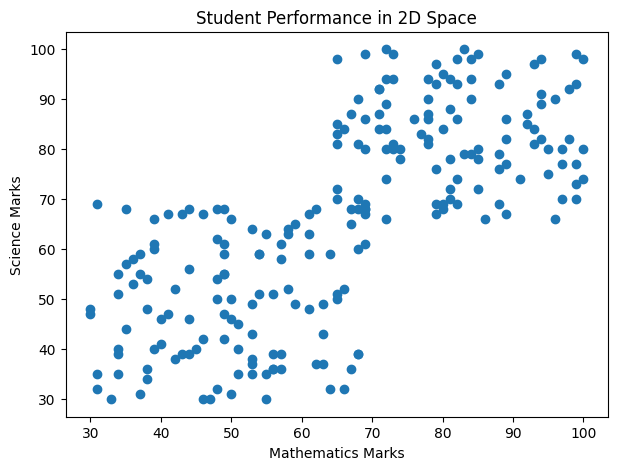

In [11]:
plt.figure(figsize=(7,5))


plt.scatter(
    data["Math"],
    data["Science"]
)


plt.xlabel("Mathematics Marks")

plt.ylabel("Science Marks")

plt.title("Student Performance in 2D Space")


plt.show()

# Part D - Eigenvalues, LU and SVD ⚙️

# 🔍 Advanced Matrix Analysis

Eigenvalues and eigenvectors show important directions of variation.

LU decomposition breaks a matrix into:

A = L × U

SVD represents a matrix using:

A = U × S × Vᵀ

In [12]:
cov_matrix = np.cov(student_data.T)


values,vectors = eig(cov_matrix)


print("Eigenvalues:")

print(values)


print("\nEigenvectors:")

print(vectors)

Eigenvalues:
[1999.89559008   88.35121018  103.922446    109.74130415  126.83299744
  142.44153742  140.42315467]

Eigenvectors:
[[ 0.37557745  0.6042064   0.52565501 -0.20020852 -0.103804    0.40678429
   0.03508322]
 [ 0.38958456 -0.377581    0.49629219  0.14386127  0.62178787 -0.21682402
   0.07086356]
 [ 0.37378732 -0.50108639 -0.24408613  0.01536888 -0.07770485  0.71704653
  -0.17084338]
 [ 0.38400961 -0.31456246  0.20118545 -0.23840492 -0.68186047 -0.43376102
  -0.05650012]
 [ 0.37767006  0.31058944 -0.2862704   0.19368316  0.13555141 -0.24548089
  -0.75020035]
 [ 0.36088755  0.11650493 -0.48605101 -0.62650202  0.28727901 -0.14360838
   0.35253908]
 [ 0.38355001  0.17969669 -0.24316848  0.6724057  -0.17529808 -0.06576704
   0.52372076]]


In [13]:
P,L,U = lu(matrix_A)


print("Lower Matrix L:")

print(L)


print("\nUpper Matrix U:")

print(U)

Lower Matrix L:
[[ 1.          0.          0.          0.          0.          0.
   0.        ]
 [ 0.46428571  1.          0.          0.          0.          0.
   0.        ]
 [ 0.79761905  0.06780349  1.          0.          0.          0.
   0.        ]
 [ 0.86904762  0.42103126  0.04243347  1.          0.          0.
   0.        ]
 [ 0.58333333 -0.13926106 -0.32455124  0.6948282   1.          0.
   0.        ]
 [ 0.46428571  0.11327649 -0.93774074  0.19954922  0.11460772  1.
   0.        ]
 [ 0.67857143  0.25213155 -0.30301352  0.40933396  0.29885546  0.88355661
   1.        ]]

Upper Matrix U:
[[ 84.          79.          79.          66.          77.
   90.          86.        ]
 [  0.          29.32142857  18.32142857   3.35714286   3.25
  -10.78571429  -4.92857143]
 [  0.           0.         -32.25416159   5.12951685   4.36297199
  -29.0544052  -18.26106374]
 [  0.           0.           0.          34.01173183  31.52984567
   19.55971652  28.11186778]
 [  0.           0.  

In [14]:
U_matrix,S_values,Vt_matrix = svd(
    student_data,
    full_matrices=False
)


print("Singular Values:")

print(S_values)

Singular Values:
[2683.09668436  176.62043644  175.44438475  166.66764284  155.31104894
  151.20402666  139.14520791]


# Part E - Principal Component Analysis (PCA) 📉

# 📉 PCA Dimensionality Reduction

PCA reduces the number of dimensions while keeping maximum information.

Here 7 subject features are converted into 2 major components.

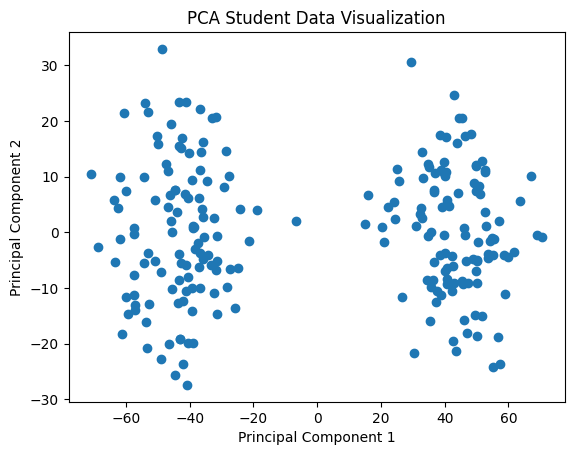

In [15]:
pca_model = PCA(n_components=2)


pca_result = pca_model.fit_transform(student_data)


plt.scatter(
    pca_result[:,0],
    pca_result[:,1]
)


plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Student Data Visualization")


plt.show()

In [16]:
print("Variance captured by components:")

print(
    pca_model.explained_variance_ratio_
)

Variance captured by components:
[0.73753117 0.05253028]


# Linear Discriminant Analysis (LDA) 🎯

# 🎯 LDA Classification

LDA is used to separate different groups.

In this project it separates students based on their performance category.

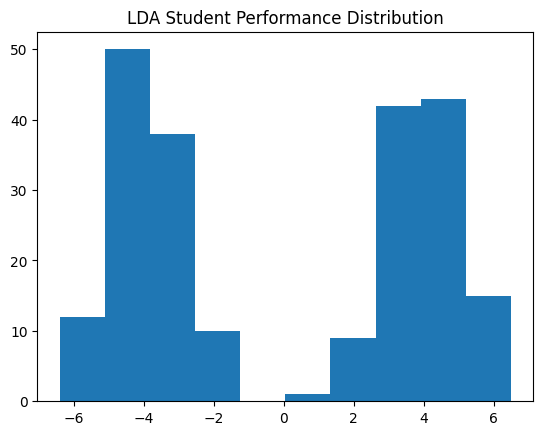

In [17]:
lda_model = LinearDiscriminantAnalysis(
    n_components=1
)


lda_result = lda_model.fit_transform(
    student_data,
    data["Category"]
)



plt.hist(lda_result)


plt.title("LDA Student Performance Distribution")


plt.show()

In [18]:
print(
    "Student Category Count:"
)


print(
    data["Category"].value_counts()
)

Student Category Count:
Category
Below Average    110
Above Average    110
Name: count, dtype: int64


# 🎉 Conclusion

This project successfully implemented Linear Algebra concepts on student performance data.

## Interpretation:

📌 PCA reduces data dimensions while preserving important information.

📌 Eigenvalues represent the importance of different directions in data.

📌 LDA helps separate students into performance groups.

📌 Linear Algebra provides powerful tools for understanding real-world datasets.